# Natural Dust service Tool

This notebook presents a prototype of the <u>**CAMS Natural Dust service Tool**</u> designed to support EU Member States in identifying and assessing natural contributions from dust to PM10 concentrations, as requested by Article 16 of the Air Quality Directive (AAQD 2024/2881). The tool aims to calculate and subtract these natural dust contributions from measured PM10 concentrations to provide corrected PM10 surface concentrations.

> AAQD (2024/2881) Article 16: Member states are requested to identify a) zones where exceedances of limit values for a given pollutant are attributable to natural sources and b) average exposure territorial units, where exceedances of the level determined by the average exposure reduction obligations are attributable to natural sources.

This *natural dust service tool prototype* is based on the methodology provided in the European Commission DG-ENV  guidelines ([sec 2011-0208](https://data.consilium.europa.eu/doc/document/ST%206771%202011%20INIT/EN/pdf)) for the assessment of the natural contributions from dust, which needs to be followed to allow subtraction of these contributions from the reported PM concentrations.
For flagging the presence of natural dust the CAMS interim reanalysis dust product is used.

This prototype is demonstrating the methodology and applications of the tool for 2024 and daily EEA data in Spain.

# Outline
- [ 1 - Import Packages ](#1)
- [ 2 - Country selection and Threshold settings](#2)
- [ 3 - Data preparation ](#3)
- [ 4 - Flag dust days with CAMS data](#4)
- [ 5 - Calculate dust for days with dust and exceedance](#5)
- [ 6 - Table with results](#6)
- [ 7 - Visualization](#7)

<a name="1"></a>
## 1 - Import Packages

Output should show in the lastline:

> util.py has been imported




In [ ]:
# %%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests
import os
import glob
import zipfile
#!pip install xarray netcdf4
!pip install "cdsapi>=0.7.7"
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import urllib.request
import json
import io
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
# raw_url="https://raw.githubusercontent.com/jessieaha/CAMS_dust_deduction_tool/main/util.py"
# dest = Path('util.py')
# urllib.request.urlretrieve(raw_url, dest)
from util import *
print(until_check())

util.py has been imported



<details>
<summary><font size="2" color="darkgreen"><b>Please Click here if errors appear</b></font></summary>
Remove <font size="2" color="blue"> <b>%%capture</b></font> and output should show in the end:

> util.py has been imported

If functions are modified in util.py please reload the file use the code below
```
import sys, importlib, os, inspect
import util
importlib.invalidate_caches()
if 'util' in sys.modules:
    del sys.modules['util']
import util
importlib.reload(util)  # extra safety

# Double-check the function exists and from which file it's loaded
print("Has function?", hasattr(util, 'plot_station_timeseries'))
if hasattr(util, 'plot_station_timeseries'):
    print(inspect.getsource(util.plot_station_timeseries)[:400])  # peek at the first lines

```
If one of the modules are not loading  try

```
pip install xxxx
```
If you plan to run this notebook in the VScode or in HPC environment, the widget from interactive plot might not work but you can modify the code by inputing correct column to generate static plots. Cheers!




<a name="2"></a>
## 2- Country selection and Threshold settings
Choose the country of interest for downloading the observation data. Note that only SPAIN (ES) is available in this prototype based on a predownloaded daily EEA dataset.

In the final tool you will be able to select other countries to download daily or hourly EEA datasets (E1a or E2a) for chosen year. You will also be able to choose to use your own observation dataset.
<center>


| Country Code | Country Name           | Country Code | Country Name           |
|-------------|-------------------------|-------------|-------------------------|
| AD          | Andorra                | IT          | Italy                  |
| AL          | Albania                | LT          | Lithuania              |
| AT          | Austria                | LU          | Luxembourg             |
| BA          | Bosnia and Herzegovina | LV          | Latvia                 |
| BE          | Belgium                | ME          | Montenegro             |
| BG          | Bulgaria               | MK          | North Macedonia        |
| CH          | Switzerland            | MT          | Malta                  |
| CY          | Cyprus                 | NL          | Netherlands            |
| CZ          | Czechia                | NO          | Norway                 |
| DE          | Germany                | PL          | Poland                 |
| DK          | Denmark                | PT          | Portugal               |
| EE          | Estonia                | RO          | Romania                |
| ES          | Spain                  | RS          | Serbia                 |
| FI          | Finland                | SE          | Sweden                 |
| FR          | France                 | SI          | Slovenia               |
| GB          | United Kingdom         | SK          | Slovakia               |
| GR          | Greece                 | XK          | Kosovo                |  
| HR          | Croatia                |             |                         |
| HU          | Hungary                |             |                         |
| IE          | Ireland                |             |                         |
| IS          | Iceland                |             |                         |




In [ ]:
###############Prototype read-only#############
project_dir          = '.'
dataset              = 'E1a'
EEA_folder_path      = f'Data/EEA_PM10/{dataset}'
CAMS_folder_path     =f'Data/CAMS/'
DOWNLOAD_EEA         = True
EEA_temporal_flag    = 'hour'    # hour or day
DOWNLOAD_CAMS        = True
COMPUTE_CAMS_DAILY   = True
YEAR                 = 2024      # int: target year
Countries            = ['ES']    # it can be multiple or one
base_url = "https://policy.atmosphere.copernicus.eu/api/"


In [ ]:
if (DOWNLOAD_EEA):
    from datetime import datetime
    # Specify download path
    os.makedirs(EEA_folder_path, exist_ok=True)

    apiUrl = "https://eeadmz1-downloads-api-appservice.azurewebsites.net/"
    endpoint = "ParquetFile/async"

    fileName = os.path.join(EEA_folder_path, f"EEA_{YEAR}.zip")
    request_body = {
        "countries": Countries,
        "cities": [],
        "pollutants": ["PM10"],
        "dataset": 2,
        "dateTimeStart": f"{YEAR-1}-12-14T00:00:00Z",
        "dateTimeEnd": "2024-12-31T23:59:59Z",
        "aggregationType": EEA_temporal_flag,
        "email": ""
    }

    response = requests.post(f"{apiUrl}{endpoint}", json=request_body)
    downloadFile = response.text
    print(downloadFile)

    t_start = datetime.now()
    while True:
        if (datetime.now() - t_start).total_seconds() > 3600:  # stop after 1 hour if the file has not been created
            break
        parquetResponse = requests.get(downloadFile)
        if parquetResponse.status_code == 404:
            time.sleep(20)
        else:
            break

    with open(fileName, "wb") as fp:
        fp.write(parquetResponse.content)

    with zipfile.ZipFile(fileName, 'r') as zip_ref:
        zip_ref.extractall(downloadPath)
##############################################
##################cams data###################
##############################################

netcdf_files = glob.glob(os.path.join(project_dir, 'IRA_dust/cams.eaq.ira.ENSa.dust*.nc'))
print(netcdf_files)
# datasets = [xr.open_dataset(file) for file in netcdf_files]
# cams = xr.concat(datasets, dim='time')
# cams = cams.sortby('time')
# data has been calculated loaded instead
if COMPUTE_CAMS_DAILY:
    cams =  xr.open_mfdataset(
        netcdf_files,
        combine='by_coords',
        parallel=True,
        chunks={'time': 96},               # light time chunking on open
        compat='no_conflicts',
        join='outer'
    )
    cams = cams.sortby('time')
    daily_cams = cams.resample(time='1D').mean(keep_attrs=True).compute()
    daily_cams.to_netcdf(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")
    cams.close()
else:
    daily_cams = xr.open_mfdataset(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")
print('cams dust source:')
print(daily_cams['dust'].dims)
print(f'cams dust unit:')
print(daily_cams['dust'].units)
print(f'cams dust dimension:')
print(daily_cams['dust'].units)
# daily data are local time zone but hourly data is in UTC+1

Please go to https://cds.climate.copernicus.eu/how-to-api to see how to use cdsapi
if you already have an account but forgot your key please go to your profile and copy API key like below.
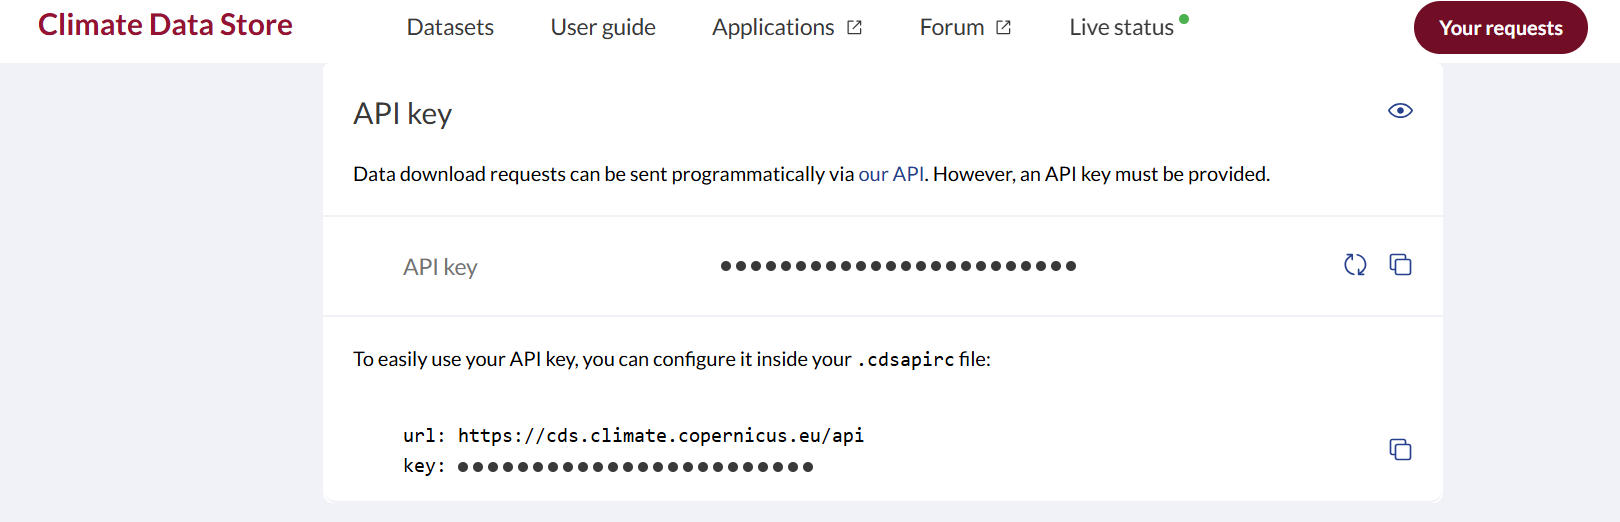

In [ ]:
import os

# Ask for user input
api_key = input("Enter your Copernicus CDS API Key: ")

# Define the content and path
path = os.path.expanduser('~/.cdsapirc')
content = f"""url: https://cds.climate.copernicus.eu/api
key: {api_key}"""

# Write the file
with open(path, 'w') as f:
    f.write(content)

print(f"\nSuccess! .cdsapirc has been created at {path}")

In [1]:
import cdsapi
cams_downloads = [
    {"filename": "cams_2023.zip", "year": [f"{str:(YEAR-1)}"], "month": ["12"]},
#     {"filename": "cams_Q1.zip", "year": [f"{YEAR}"], "month": ["01","02","03"]},
#     {"filename": "cams_Q2.zip", "year": [f"{YEAR}"], "month": ["04","05","06"]},
#     {"filename": "cams_Q3.zip", "year": [f"{YEAR}"], "month": ["07","08","09"]},
#     {"filename": "cams_Q4.zip", "year": [f"{YEAR}"], "month": ["10","11","12"]}
 ]

dataset = "cams-europe-air-quality-reanalyses"
client = cdsapi.Client()

for config in cams_downloads:
    filename = os.path.join(CAMS_folder_path, config["filename"])
    request = {
        "variable": ["dust"],
        "model": ["ensemble"],
        "level": ["0"],
        "type": ["interim_reanalysis"],
        "year": config["year"],
        "month": config["month"]
    }

    client.retrieve(dataset, request).download(filename)


ModuleNotFoundError: No module named 'cdsapi'

In [ ]:
import cdsapi
#test
dataset = "cams-europe-air-quality-reanalyses"
request = {
    "variable": ["dust"],
    "model": ["ensemble"],
    "level": ["0"],
    "type": ["interim_reanalysis"],
    "year": ["2024"],
    "month": [
        "01"
    ]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-02-02 14:19:52,631 WARNING [2026-02-02T13:19:52.613108] You are using a deprecated API endpoint. If you are using cdsapi, please upgrade to the latest version.
2026-02-02 14:19:52,632 INFO Request ID is f4b9de14-3a9c-4a95-890d-ee4b6488621d
2026-02-02 14:19:52,703 INFO status has been updated to accepted
2026-02-02 14:20:12,810 INFO status has been updated to running


KeyboardInterrupt: 


For flexibility considering changes in future guidelines including different limit values, the user can modify the threshold here:


1.   Set the CAMS dust concentration threshold used for flagging a day as 'dust day'
2.   Set the threshold for the PM10 limit value (you can for example choose to use the old or new AAQD limit values)
3.   Set the minimum % of data coverage to allow inclusion of the eea measurements



In [ ]:
##################User Editable######################
CAMS_dust_threshold         = 5         # unit: µg/m3
PM10_daily_threshold        = 50        # 50 µg m-3
Station_Temporal_coverage   = 65        # in % of temporal coverage per whole year for each EEA station
##################STOP Editing######################

<a name="3"></a>
## 3- Data preparation
In this step the EEA data including metadata is downloaded, filtered for validity, verification status and data coverage (using the minimum value set in step 2).

Note that in the prototype, we only provide pre-downloaded EEA daily air quality data for Spain as a demonstration.

In the final tool, you will be able to use the tool to download any EEA dataset—either hourly or daily. Please note that the final tool may differ slightly from this prototype, as the prototype is optimized for efficiency and speed.

[Go to download script](#download)

In [ ]:
netcdf_files = glob.glob(os.path.join(project_dir, 'IRA_dust/cams.eaq.ira.ENSa.dust*.nc'))
print(netcdf_files)
# datasets = [xr.open_dataset(file) for file in netcdf_files]
# cams = xr.concat(datasets, dim='time')
# cams = cams.sortby('time')
# data has been calculated loaded instead
if COMPUTE_CAMS_DAILY:
    cams =  xr.open_mfdataset(
        netcdf_files,
        combine='by_coords',
        parallel=True,
        chunks={'time': 96},               # light time chunking on open
        compat='no_conflicts',
        join='outer'
    )
    cams = cams.sortby('time')
    daily_cams = cams.resample(time='1D').mean(keep_attrs=True).compute()
    daily_cams.to_netcdf(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")
    cams.close()
else:
    daily_cams = xr.open_mfdataset(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")
print('cams dust source:')
print(daily_cams['dust'].dims)
print(f'cams dust unit:')
print(daily_cams['dust'].units)
print(f'cams dust dimension:')
print(daily_cams['dust'].units)

### Load EEA data

In [ ]:
# Create a session and increase the connection pool size
session = requests.Session()
adapter = requests.adapters.HTTPAdapter(
    pool_connections=50,   # More simultaneous connections to your server
    pool_maxsize=50,
    max_retries=3
)
session.mount('https://', adapter)

# 1. Get the list of parquet files
list_url = f"{base_url}list/notebooks/EEA_data_{country}/E1a"
response = session.get(list_url)
response.raise_for_status()
parquet_files = [f for f in response.json()["files"] if f.endswith(".parquet")]

print(f"Found {len(parquet_files)} parquet files")

# 2. Function to download and partially process one file
def load_station_parquet(filename):
    url = f"{base_url}file/notebooks/EEA_data_{country}/E1a/{filename}"
    try:
        resp = session.get(url, timeout=60)
        resp.raise_for_status()
        df = pd.read_parquet(
            io.BytesIO(resp.content),
            columns=['Start', 'Value', 'Validity', 'Verification', 'Samplingpoint']  # Only load what we need
        )
        df = df.rename(columns={'Value': 'observed_PM10'})
        df['observed_PM10'] = df['observed_PM10'].astype('float32')
        return df
    except Exception as e:
        print(f"Failed to load {filename}: {e}")
        return pd.DataFrame()  # Return empty DF on error

# 3. Parallel download (adjust max_workers if needed)
max_workers = 20  # Colab handles 15–30 well; higher = faster but watch RAM
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    dataframes = list(executor.map(load_station_parquet, parquet_files))

# Remove any empty dataframes from errors
dataframes = [df for df in dataframes if not df.empty]

# 4. Final processing
obs = pd.concat(dataframes, ignore_index=True)
obs['Start'] = pd.to_datetime(obs['Start'])
obs['Exceedance'] = obs['observed_PM10'] > 50

print('Below is the top 5 observation points:')
obs.head()

Found 704 parquet files
Below is the top 5 observation points:


,Start,observed_PM10,Validity,Verification,Samplingpoint,Exceedance
0,2023-12-01,5.0,1,1,ES/SP_01059009_10_M,False
1,2023-12-02,5.0,1,1,ES/SP_01059009_10_M,False
2,2023-12-03,6.0,1,1,ES/SP_01059009_10_M,False
3,2023-12-04,6.0,1,1,ES/SP_01059009_10_M,False
4,2023-12-05,10.0,1,1,ES/SP_01059009_10_M,False


### Filter for validity and verification
Validity and Verification definitions from EEA:
|ID     | Label                                       | Status    | Status Modified | Notation |
|-------|---------------------------------------------|-----------|-----------------|----------|
| -99   | Not valid due to station maintenance or calibration       | Valid           | 22.03.2013 | -99 |
| -1    | Not valid                                                 | Valid           | 22.03.2013 | -1  |
| 1     | Valid                                                     | Valid           | 22.03.2013 | 1   |
| 2     | Valid, but below detection limit measurement value given  | Valid           | 22.03.2013 | 2   |
| 3     | Valid, but below detection limit and number replaced by 0.5*detection limit | Valid           | 22.03.2013 | 3   |
| 4     | Valid (Ozone only) using CCQM.O3.2019                     | Valid           | 04.07.2024 | 4   |


#### Verified code
| Id | Label                  | Status | Status Modified | Notation |
|----|------------------------|--------|-----------------|----------|
| 1  | Verified              | Valid  | 22.03.2013      | 1        |
| 2  | Preliminary verified  | Valid  | 22.03.2013      | 2        |
| 3  | Not verified          | Valid  | 22.03.2013      | 3        |
 <br>

### Filter temporal range
Only keep stations that contain 2024 data. Predownloaded set covers also some period before and/or after 2024 for later computation of moving averages.

In [ ]:
#Count and filter observation data
print(f"Number of observations before filtering: {obs.shape[0]:,}; number of stations {len(obs['Samplingpoint'].unique())}")

obs = obs[obs['Validity'] == 1]
print(f"Number of observations after validity filter:{obs.shape[0]:,}")

obs = obs[obs['Verification'] <= 2]
print(f"Number of observations after verification filter: {obs.shape[0]:,}")

obs = obs[obs['Samplingpoint'].isin(obs.query("'2024-01-01' <= Start < '2025-01-01'")['Samplingpoint'])]
print(f"Observations after filtering: {obs.shape[0]:,}, and stations {len(obs['Samplingpoint'].unique())}")

Number of observations before filtering: 37,813; number of stations 115
Number of observations after validity filter:29,796
Number of observations after verification filter: 29,796
Observations after filtering: 29,508, and stations 94


### Filter for data coverage per station

You can change the temporal coverage above in the [ 2 - Country Selection and Threshold settings ](#2)

In [ ]:
coverage_stats = calculate_data_coverage(obs, start='2024-01-01', end='2024-12-31', min_pct=Station_Temporal_coverage)

sufficient_stations = coverage_stats.query('sufficient_coverage').index.tolist()
obs = obs[obs['Samplingpoint'].isin(sufficient_stations)].copy()

print(f"Stations after filering with {Station_Temporal_coverage}% : {len(sufficient_stations)}")
print(f"Observations after filtering: {obs.shape[0]:,}")

Stations after filering with 65% : 71
Observations after filtering: 25,184


#### Load metadata and add exact location and timezone to observational data

In [ ]:
#Load metadata observational data
url = f"{base_url}/file/notebooks/DataExtract.csv"
metadata = pd.read_csv(url, low_memory=False)

# Retrieve stations from observational data
all_stations = pd.DataFrame({'Samplingpoint': obs['Samplingpoint'].unique()})

# Create dataframe with all stations and their location
metadata['Samplingpoint'] = metadata['Air Quality Station EoI Code'].str[:2] + '/' + metadata['Sampling Point Id']
stations = all_stations.merge(
    metadata[['Samplingpoint', 'Longitude', 'Latitude', 'Altitude','Timezone']],
    on='Samplingpoint',
    how='left'
).drop_duplicates(subset=['Samplingpoint'], keep='first')

# Add station coordinates to obs
obs = obs.merge(stations[['Samplingpoint', 'Latitude', 'Longitude','Altitude','Timezone']],
                on='Samplingpoint', how='left')
# del(stations)
print(f'Time zone for {country}')
metadata.loc[metadata['Samplingpoint'].isin(obs['Samplingpoint']), 'Timezone'].unique()


Time zone for ES


array(['UTC'], dtype=object)

### Load CAMS data

Here the CAMS interim reanalysis dust data is downloaded and processed for selected country.

This step can be memory intensive. In this prototype we provide a smaller, pre‑processed CAMS dataset extracted at EEA station locations in Spain to make the workflow more manageable.

In the final natural dust service tool, users will be able to download the complete CAMS regional interim reanalysis dust data which will then be aggregated to daily values before interpolating to all stations in their dataframe. This process typically exceeds the free memory limits available on Google Colab, so we recommend running it on a local machine or an HPC environment.
To support repeated workflows, the final natural dust service tool is intended to include functionality to compute, save, and reload these processed datasets for future use.

In [ ]:
#Load metadata observational data
url = f"{base_url}/file/notebooks/daily_cams.nc"
local_path = "daily_cams.nc"

# Download the file
urllib.request.urlretrieve(url, local_path)

# Now open it
cams = xr.open_dataset(local_path)
print('The CAMS data has been preprocessed based on local timezone.')
cams

The CAMS data has been preprocessed based on local timezone.


<xarray.Dataset> Size: 4MB
Dimensions:  (station: 1145, date: 398)
Coordinates:
  * station  (station) <U54 247kB 'HR/HR_DOC_TYPE_D_SPO_1067' ... 'ES/SP_5029...
  * date     (date) datetime64[ns] 3kB 2023-12-01 2023-12-02 ... 2025-01-01
    lat      (station) float64 9kB ...
    lon      (station) float64 9kB ...
Data variables:
    dust     (station, date) float64 4MB ...
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality interim reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service

<a name="4"></a>
## 4- Flag dust days with CAMS data

In this step the CAMS interim reanalysis dust product is used to identify days impacted by natural dust.

You can experiment with the thresholds for flagging in the [ 2 - Country Selection and Threshold Settings](#2) although we do not recommend to change the threshold for the final results.

In [ ]:
# Convert cams xarray to DataFrame
cams_df = cams.to_dataframe().reset_index()

# Rename columns to match obs DataFrame and remove double columns
cams_df = cams_df.rename(columns={'station': 'Samplingpoint', 'date': 'Start'})
cams_df = cams_df.drop(columns=['lat','lon'])

# Ensure 'Start' is datetime in both DataFrames
cams_df['Start'] = pd.to_datetime(cams_df['Start'])
df_processed = obs.copy()
df_processed['Start'] = pd.to_datetime(df_processed['Start'])

# Merge on Samplingpoint and Start
df_processed = df_processed.merge(cams_df, on=['Samplingpoint', 'Start'], how='left')

# Rename dust to cams_dust
df_processed = df_processed.rename(columns={'dust': 'cams_dust'})

# Flag dust days for cams dust > 5 µg/m³ or treshold selected
df_processed['dust_flag'] = df_processed['cams_dust'] > CAMS_dust_threshold
print('Blow shows the new table with dust flag and Exceedance')
df_processed.head()

Blow shows the new table with dust flag and Exceedance


,Start,observed_PM10,Validity,Verification,Samplingpoint,Exceedance,Latitude,Longitude,Altitude,Timezone,cams_dust,dust_flag
0,2023-12-01,14.0,1,1,ES/SP_03009006_10_M,False,38.70639,-0.46694,534.0,UTC,0.515081,False
1,2023-12-02,7.0,1,1,ES/SP_03009006_10_M,False,38.70639,-0.46694,534.0,UTC,0.118658,False
2,2023-12-03,5.0,1,1,ES/SP_03009006_10_M,False,38.70639,-0.46694,534.0,UTC,0.100739,False
3,2023-12-04,4.0,1,1,ES/SP_03009006_10_M,False,38.70639,-0.46694,534.0,UTC,0.106475,False
4,2023-12-05,5.0,1,1,ES/SP_03009006_10_M,False,38.70639,-0.46694,534.0,UTC,0.062206,False


Check if any stations are missing from the CAMS dataset:

In [ ]:
# Get Samplingpoint values in cams_df that are NOT present in obs['Samplingpoint']
obs.loc[~obs['Samplingpoint'].isin(cams_df['Samplingpoint']), 'Samplingpoint'].unique()

array(['ES/SP_12046001_10_M'], dtype=object)

<a name="5"></a>
## 5 - Calculate dust for days with dust and exceedance
Based on the start day/time of the measurements, this cell below will calculate the rolling windows of 30 days moving average median (5oth percentile) for all non-dusty days.

This is considered as the background PM10 without dust.

In [ ]:
# compute_median_for_station: calculated the 50th percentile of a rolling 30 window excluding dust days per location

# Filter 2024 data
obs_2024 = df_processed[(df_processed['Start'] >= '2024-01-01') & (df_processed['Start'] < '2025-01-01')].copy()
obs_2024['PM10_median'] = np.nan

# Apply per station using groupby
obs_2024['PM10_median'] = (
    df_processed.groupby(['Samplingpoint','Timezone','Latitude','Longitude','Altitude'], group_keys=False)
         .apply(compute_median_for_station) # if warning appears add: , include_groups=False
)


/tmp/ipython-input-3344938587.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_median_for_station) # if warning appears add: , include_groups=False


Here, the tool calculates the natural dust contribution and removes it from the PM10 in cases where the station has a flagged dust day and the PM10 exceeds the selected treshold value.

In [ ]:

obs_2024['observed_PM10'] = pd.to_numeric(obs_2024['observed_PM10'], errors='coerce')
obs_2024['PM10_median']   = pd.to_numeric(obs_2024['PM10_median'],   errors='coerce')

# Initialize dust column with NaN
obs_2024['dust'] = np.nan
obs_2024['dust'] = obs_2024['dust'].astype(float)


# Calculate dust only for rows where dust_flag & Exceedance are True
mask = obs_2024['dust_flag'] & obs_2024['Exceedance'] & obs_2024['PM10_median'].notna()

# Compute dust = observed_PM10 - PM10_median for masked rows
obs_2024.loc[mask, 'dust'] = obs_2024.loc[mask, 'observed_PM10'] - obs_2024.loc[mask, 'PM10_median']

# Create corrected_PM10 column: start with observed_PM10
obs_2024['corrected_PM10'] = obs_2024['observed_PM10'].astype(float)

# Subtract dust only for masked rows
obs_2024.loc[mask, 'corrected_PM10'] = obs_2024.loc[mask, 'observed_PM10'] - obs_2024.loc[mask, 'dust']

print('Below is how the data structure looks like now: ')
for col in obs_2024.columns:
    print(col)


Below is how the data structure looks like now: 
Start
observed_PM10
Validity
Verification
Samplingpoint
Exceedance
Latitude
Longitude
Altitude
Timezone
cams_dust
dust_flag
PM10_median
dust
corrected_PM10


Next, we count the number of  exceedance days (*Exceedance_days*), exceedance days due to dust, i.e. where the exceedance is removed when we subtract the calculated natural dust contribution (*Dust_exceedance_days*, ) and corrected exceedance days after removing the calculated natural dust contributions (*NonDust_exceedance*)

In addition the annual average PM10 concentration observed by the EEA station is calculated aswell as the corrected annual average PM10 where the calculated natural dust contributions are removed (*corrected_PM10*).



In [ ]:

# Dust exceedance flag (observed exceeds but corrected does not)
obs_2024['Dust_exceedance'] = (
    (obs_2024['observed_PM10']  > PM10_daily_threshold) &
    (obs_2024['corrected_PM10'] <= PM10_daily_threshold)
)

# One-pass aggregation per station. For metadata columns that should be constant per station,
# we take 'first'. If they can vary, consider 'median' or a custom reducer.
station_table = (
    obs_2024
    .groupby('Samplingpoint', as_index=False)
    .agg(
        # Station metadata (kept from obs_2024)
        Latitude=('Latitude', 'first'),
        Longitude=('Longitude', 'first'),
        Altitude=('Altitude', 'first'),
        Timezone=('Timezone', 'first'),

        # Metrics
        Exceedance_days=('Exceedance', 'sum'),
        Dust_exceedance_days=('Dust_exceedance', 'sum'),
        Average_PM10=('observed_PM10', 'mean'),
        Average_PM10_dust_removed=('corrected_PM10', 'mean'),
    )
)

# Derived metric
station_table['NonDust_exceedance'] = (
    station_table['Exceedance_days'] - station_table['Dust_exceedance_days']
)

# Optional: reorder columns for readability
station_table = station_table[
    [
        'Samplingpoint', 'Latitude', 'Longitude', 'Altitude', 'Timezone',
        'Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance',
        'Average_PM10', 'Average_PM10_dust_removed'
    ]
]
station_table


,Samplingpoint,Latitude,Longitude,Altitude,Timezone,Exceedance_days,Dust_exceedance_days,NonDust_exceedance,Average_PM10,Average_PM10_dust_removed
0,ES/SP_03009006_10_M,38.70639,-0.46694,534.0,UTC,5,5,0,14.336158,13.490113
1,ES/SP_03014006_10_M,38.35944,-0.47194,45.0,UTC,6,6,0,21.322857,20.324286
2,ES/SP_03065006_10_M,38.24222,-0.68278,44.0,UTC,9,8,1,20.406340,19.162824
3,ES/SP_03065007_10_M,38.25917,-0.71750,99.0,UTC,5,4,1,21.244095,20.129921
4,ES/SP_03105001_10_M,38.45167,-1.06472,642.0,UTC,5,5,0,14.033613,13.271709
...,...,...,...,...,...,...,...,...,...,...
66,ES/SP_46263999_10_M,39.08278,-1.10083,855.0,UTC,8,7,1,13.374302,12.103352
67,ES/SP_49149999_10_M,41.23889,-5.89742,1003.0,UTC,5,3,2,8.952381,8.354167
68,ES/SP_50008001_10_M,41.76280,-1.14330,235.0,UTC,4,3,1,16.162983,15.839779
69,ES/SP_50067001_10_M,41.35457,-1.65257,600.0,UTC,2,2,0,10.960606,10.469697


#### Check for negative data
Next, we check whether any negative values occur in the corrected PM10 dataset.

Using a 30‑day moving average can sometimes yield a higher “background” concentration than the concentration during the dust impacted day because the method relies on the median. During dust events, strong winds may actually reduce local PM10 levels at certain stations, meaning that some “dusty days” can appear cleaner than typical background days. As a result, the corrected PM₁₀ (which is calculated as the measured concentration minus the estimated background) can become negative.



In [ ]:
negative_dust = obs_2024['dust']<0
negative_dust.sum()

np.int64(0)

<a name="6"></a>
## 6 - Final table with results for all stations

Below you find the final table containing all stations and their results.
You can save the data to a csv file.

The annual file contains for selected year for each station the number of exceedance days and annual average PM10 before and after natural dust subtraction.

The daily file contains the information per stations for each day of the year, including: measured PM10 concentration, occurence of exceedance of limit value, cams dust concentration, dust flag, background PM10, calculated natural dust contribution, corrected PM10 concentration and if the exceedance was due to natural dust.   

 The csv files can be found and downloaded under the file folder tab in the left colum of pictograms as can be seen in the screenshot below.

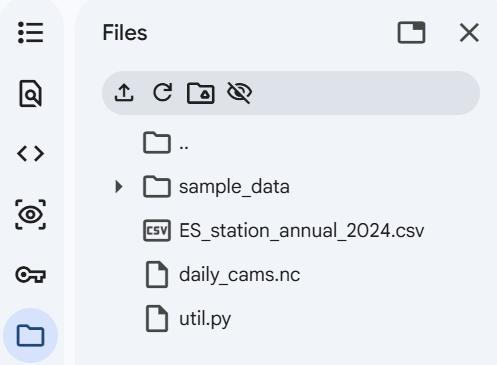


In [ ]:
station_table
# If you would like to save this file please uncomment the line below
#station_table.to_csv(f'{country}_station_annual_{YEAR}.csv') #aggregated stations average data
#obs_2024.to_csv(f'{country}_station_daily_{YEAR}.csv') #daily data

,Samplingpoint,Latitude,Longitude,Altitude,Timezone,Exceedance_days,Dust_exceedance_days,NonDust_exceedance,Average_PM10,Average_PM10_dust_removed
0,ES/SP_03009006_10_M,38.70639,-0.46694,534.0,UTC,5,5,0,14.336158,13.490113
1,ES/SP_03014006_10_M,38.35944,-0.47194,45.0,UTC,6,6,0,21.322857,20.324286
2,ES/SP_03065006_10_M,38.24222,-0.68278,44.0,UTC,9,8,1,20.406340,19.162824
3,ES/SP_03065007_10_M,38.25917,-0.71750,99.0,UTC,5,4,1,21.244095,20.129921
4,ES/SP_03105001_10_M,38.45167,-1.06472,642.0,UTC,5,5,0,14.033613,13.271709
...,...,...,...,...,...,...,...,...,...,...
66,ES/SP_46263999_10_M,39.08278,-1.10083,855.0,UTC,8,7,1,13.374302,12.103352
67,ES/SP_49149999_10_M,41.23889,-5.89742,1003.0,UTC,5,3,2,8.952381,8.354167
68,ES/SP_50008001_10_M,41.76280,-1.14330,235.0,UTC,4,3,1,16.162983,15.839779
69,ES/SP_50067001_10_M,41.35457,-1.65257,600.0,UTC,2,2,0,10.960606,10.469697


<a name="7"></a>
## 7 - Visualization
The tool provides both interactive and static plots.

If interactive animation like ipywidgets does not work in your environment, skip the cell below to go to the next cell to plot the static stations plot.



### Map - Corrected annual average PM10 and number of exceedances days

In this section, the corrected annual average PM10 (after subtraction of natural dust contributions) and corrected number of exceedances days (non-dust impacted exceedance days) per station is visualised in an interactive window. Move your cursor to the station location to show the results.

In [ ]:

# # Call the defined function to plot the interactive map with new options
# plot_interactive_station_map(
#     df=station_table,
#     color_column='Average_PM10_dust_removed',
#     size_column='NonDust_exceedance',
#     color_type='continuous_scale', # Explicitly continuous
#     colorscale='RdBu_r',
#     zoom=5,
#     map_title='Corrected PM10 concentration (colorbar) and corrected nr. of exceedance days (size of dots)',
#     colorbar_title='µg/m³',
#     size_legend_min=1,
#     size_legend_max=19,
#     size_legend_steps=3,
#     marker_size_range=[20, 40]
# )




### Plot station timeseries


On the interactive map below you can select a station and click to plot the timeseries of measured and corrected PM10.

Color and size of the dots indicate the average PM10 concentration before removing the natural dust contribution.

In [ ]:
# interactive_map_widget = map_timeseries_clickable_plot(
#     obs_df=obs_2024,
#     year=YEAR,
#     exceedance_threshold=PM10_daily_threshold,
#     cams_dust_threshold=CAMS_dust_threshold,
#     legend_title='Average observed PM10 (µg/m³)',
#     legend_bins=7,
#     legend_round=0,
#     radius_range=(8, 16)
# )
# display(interactive_map_widget)

### Static timeseries
If the interactive maps above do not work you can copy the sations name and input below: Remember to uncomment the lines.

In [ ]:
# @title
# ########### USER INPUT ##############
# # print(stations)
# station_name = 'ES/SP_43004006_10_M' # specify station to plot
# #####################################
# # Plot timeseries for this station
# fig, ax = plot_station_timeseries(station_name, obs_2024,
#                        year = YEAR,
#                        exceedance_threshold= PM10_daily_threshold,
#                       cams_dust_threshold= CAMS_dust_threshold)

### Static Map exceedance days

Static plot:

You can chose the column to plot from the station table.

For Custom color option:
https://matplotlib.org/stable/gallery/color/colormap_reference.html

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip



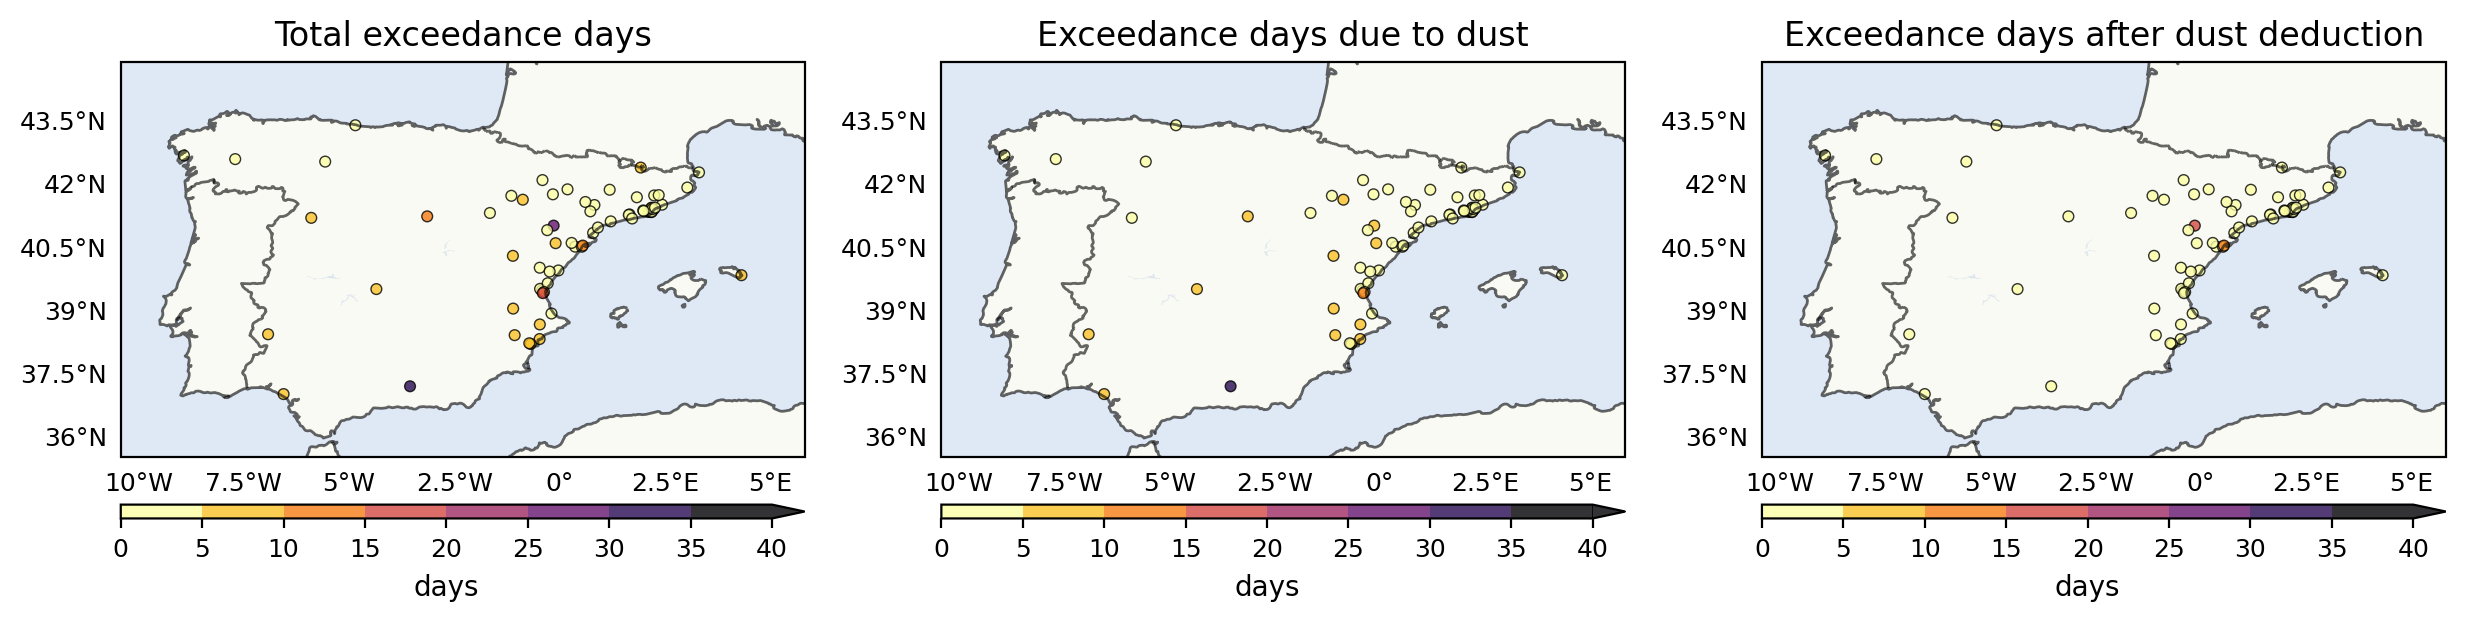

In [ ]:
###################Edit here#########################
columns_to_plot = ['Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance']
titles = [
    'Total exceedance days',
    'Exceedance days due to dust',
    'Exceedance days after dust deduction'
]
vmax_value = 40
n_colors = 8
colormap='inferno_r' # see https://matplotlib.org/stable/gallery/color/colormap_reference.html for options, for example Set1 gistheat_r twilight
###################Stop here#########################
plot_exceedance_maps_discrete(
    station_table, columns_to_plot, titles, vmax_value,    # data
    n_colors=n_colors,cbar_text='days',cmap_name=colormap, # color setup
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",
    cbar_size="3.5%", cbar_pad="12%"                        # size >3% and pad 12% horizontal

)

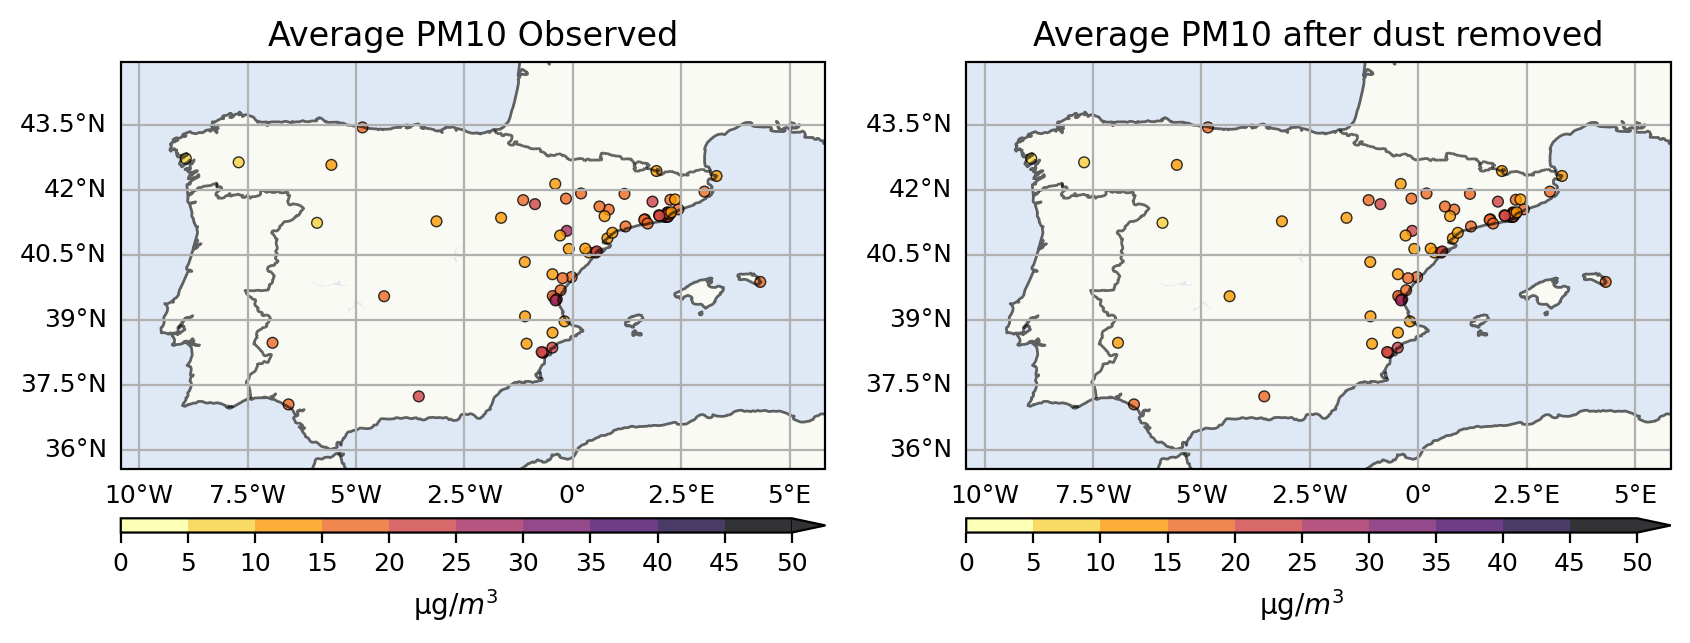

In [ ]:
###################Edit here#########################
columns_to_plot = ['Average_PM10', 'Average_PM10_dust_removed']
titles = [
    'Average PM10 Observed',
    'Average PM10 after dust removed'
]
vmax_value = 50
n_colors = 10
colormap='inferno_r' # https://matplotlib.org/stable/gallery/color/colormap_reference.html Set1 gist_heat_r twilight
###################Stop here#########################
import cartopy.crs as ccrs
plot_exceedance_maps_discrete(station_table, columns_to_plot, titles, vmax_value,
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",gridline = True,
     n_colors=n_colors,cbar_text='µg/$m^3$',cmap_name=colormap,
    cbar_size="3.5%", cbar_pad="12%" )

<a name="download"></a>
#### Download your own selection of EEA and CAMS Data

Do not use this code during demonstration
<details>
dataset: value ofthe dataset:

1. Unverifieddata transmitted continuously(Up-To-Date/UTD/E2a) data fromthe
beginning of 2023.
2. Verified data (E1a) from2013 to 2022 reported by countries by 30 September each
year for the previous year.
3. Historical Airbase datadeliveredbetween 2002 and 2012 before AirQuality
Directive 2008/50/EC entered into force.
4. Downscaled CAMS forecast at station level
5. Gap-filled E2a, using linear interpolation for smaller gaps, and a regressor
based on similar stations for larger ones.
<summary><font size="2" color="darkgreen"><b>Please Click here if you wish to download EEA data by yourself</b></font></summary>

```python
from datetime import datetime
import time
import requests
import os
import zipfile

# Specify download path
downloadPath = f'./EEA_data'
os.makedirs(downloadPath, exist_ok=True)

apiUrl = "https://eeadmz1-downloads-api-appservice.azurewebsites.net/"
endpoint = "ParquetFile/async"

fileName = os.path.join(downloadPath, f"EEA_2024_FR.zip")
request_body = {
    "countries": country,
    "cities": [],
    "pollutants": ["PM10"],
    "dataset": 2,
    "dateTimeStart": "2023-12-30T00:00:00Z",
    "dateTimeEnd": "2024-12-31T23:59:59Z",
    "aggregationType": "hour",
    "email": ""
}

response = requests.post(f"{apiUrl}{endpoint}", json=request_body)
downloadFile = response.text
print(downloadFile)

t_start = datetime.now()
while True:
    if (datetime.now() - t_start).total_seconds() > 3600:  # stop after 1 hour if the file has not been created
        break
    parquetResponse = requests.get(downloadFile)
    if parquetResponse.status_code == 404:
        time.sleep(20)  
    else:
        break

with open(fileName, "wb") as fp:
    fp.write(parquetResponse.content)

with zipfile.ZipFile(fileName, 'r') as zip_ref:
    zip_ref.extractall(downloadPath)
